# Taller Práctico: Clasificación de Riesgo Crediticio con Perceptrón
## Contexto del Problema
Una entidad financiera desea automatizar la aprobación de créditos pre-aprobados.

Se cuenta con dos variables de entrada:

* Puntaje Crediticio (Normalizado de 0 a 1).

* Ratio de Ahorro (Dinero ahorrado vs ingresos anuales).

El objetivo es entrenar un Perceptrón Simple en Keras para que aprenda la frontera de decisión que separa a los clientes de "Bajo Riesgo" (Clase 1) de los de "Alto Riesgo" (Clase 0).

## Paso 1: Preparación del Entorno
Cargamos las librerías necesarias y generamos un dataset sintético que represente este escenario.

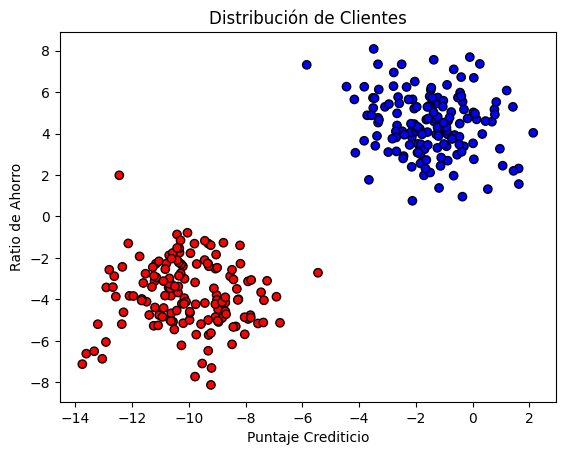

In [15]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_blobs

# Generamos datos: 300 clientes con 2 características
X, y = make_blobs(n_samples=300, centers=2, n_features=2, cluster_std=1.5, random_state=1)
# Visualización inicial
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')
plt.xlabel("Puntaje Crediticio")
plt.ylabel("Ratio de Ahorro")
plt.title("Distribución de Clientes")
plt.show()

## Paso 2: Definición de la Arquitectura (Misión del Alumno)
Debes definir un modelo secuencial que represente un Perceptrón Simple. Recuerda que para una clasificación binaria, la salida debe pasar por una función que comprima el valor entre 0 y 1.

**Guía Técnica:**

* Usa una capa Dense.

* Como es un Perceptrón de una sola capa, units debe ser igual a 1.

* El input_shape debe coincidir con la cantidad de variables de entrada (2).

In [16]:
# --- COMPLETA EL CÓDIGO AQUÍ ---
model = Sequential([
    # Define la capa Dense con 1 neurona y activación 'sigmoid'
Dense(units=1, input_shape=(2,), activation='sigmoid',)
])
# units=1, tiene solo una capa.
# input_shape=(2,), cada dato de entrada tiene 2 caracteristicas.
# activation='sigmoid', comprime entre 0 y 1

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Paso 3: Compilación del Sistema
Para que el modelo aprenda, debemos definir el Optimizador (que gestiona la Tasa de Aprendizaje) y la Función de Pérdida (que mide el error).

**Ayuda Sugerida:**

* Para clasificación binaria, la pérdida estándar es binary_crossentropy.

* Experimenta con diferentes valores en learning_rate (prueba con 0.01, 0.1 y 0.5).

In [17]:
# --- COMPLETA EL CÓDIGO AQUÍ ---
# Usa model.compile(...)
# Define el optimizer usando tf.keras.optimizers.SGD y la loss adecuada.
model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# loss= binary_crossentropy: La entropía cruzada binaria es la función de pérdida por excelencia para problemas de clasificación de dos clases.
# learning_rate: controla qué tan grandes serán los pasos que dará el modelo para ajustar sus pesos en cada iteración

## Paso 4: Entrenamiento y Regularización
Es momento de ajustar los pesos. Vamos a entrenar el modelo, pero esta vez, presta atención a cómo el número de épocas afecta el resultado.

**Instrucciones:**

* Ejecuta el método .fit().

* Prueba configurar el entrenamiento con 50 épocas.

In [18]:
# --- COMPLETA EL CÓDIGO AQUÍ ---
# history = model.fit(..., epochs=..., verbose=1)

history = model.fit(X, y, epochs=50, verbose=1)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8933 - loss: 0.4169  
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0579 
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0386 
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0300 
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0252 
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0218 
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0194 
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0176 
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0162 
Epoch 10/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0151 
Epoch 11/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0141 
Epoch 12/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy:

## Paso 5: Evaluación de Resultados
Una vez entrenado, utilizaremos el siguiente bloque para visualizar la Frontera de Decisión que tu modelo ha construido.

1024/1024 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


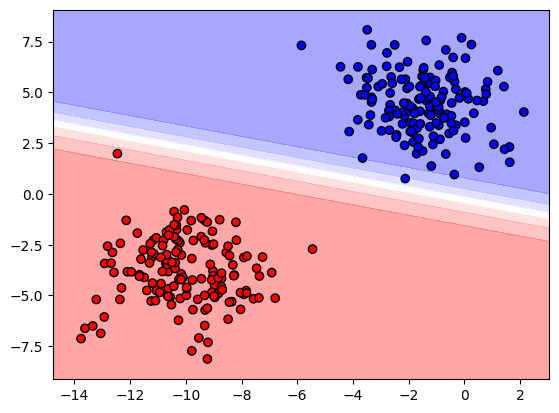

In [19]:
def plot_frontier(X, y, model):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.4, cmap='bwr')
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='bwr')
    plt.show()

plot_frontier(X, y, model)

# **Desafíos Extras**

## Impacto del Sesgo: Si imprimes los pesos del modelo con model.get_weights(), ¿cuál es el valor del Bias?
Al ejecutar model.get_weights(), el método te devolverá una lista con dos elementos de tipo NumPy array: el primero contiene los pesos asociados a las variables  y el segundo contiene el intercepto o Bias. El valor exacto dependerá de cómo haya convergido el SGD en sus 50 épocas.

## ¿Qué pasaría si fuera cero?
El sesgo actúa de forma análoga a la ordenada al origen en una ecuación lineal. Si fuera obligatoriamente cero, la frontera de decisión estaría forzada a pasar estrictamente por el origen de coordenadas. Esto limitaría enormemente al modelo, imposibilitando que clasifique correctamente conjuntos de datos cuya división óptima se encuentre desplazada del centro del gráfico.

In [14]:
model.get_weights()

[array([[-0.3382242],
        [-1.1611904]], dtype=float32),
 array([-0.6168877], dtype=float32)]

## Regularización: Regresa al Paso 2 e intenta agregar kernel_regularizer='l2' dentro de la capa Dense.

## ¿Notas algún cambio en la suavidad de la frontera o en el valor de los pesos?\
 La regularización L2 añade una penalización a la función de pérdida proporcional al cuadrado del valor de los pesos. Al entrenar, notaremos que los valores absolutos de los pesos son significativamente más pequeños.\
Visualmente, esto provoca que la frontera de decisión sea más "suave" y menos propensa a ajustarse agresivamente a puntos ruidosos (ayuda a prevenir el sobreajuste o overfitting). En un Perceptrón Simple, esto previene coeficientes gigantescos y desproporcionados.

In [27]:
model = Sequential([
    # Define la capa Dense con 1 neurona y activación 'sigmoid'
Dense(units=1, input_shape=(2,), activation='sigmoid',kernel_regularizer='l2')
])

pesos, bias = model.get_weights()

print("--- VALORES OBTENIDOS ---")
print(f"Pesos de las variables: {pesos.flatten()}")
print(f"Valor del Sesgo: {bias}")

--- VALORES OBTENIDOS ---
Pesos de las variables: [-0.40342867 -0.12931597]
Valor del Sesgo: [0.]


1024/1024 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


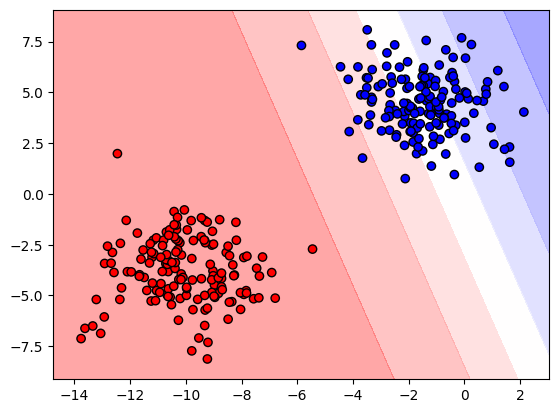

In [28]:
def plot_frontier(X, y, model):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.4, cmap='bwr')
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='bwr')
    plt.show()

plot_frontier(X, y, model)

## No Linealidad: Cambia el generador de datos por make_moons(n_samples=300, noise=0.1).

## ¿Es capaz el Perceptrón de una sola capa de separar estos datos? Justifica basándote en la teoría de Separabilidad Lineal.

No, no es capaz. El algoritmo matemático del Perceptrón Simple sin capas ocultas genera intrínsecamente un combinador lineal. Al pasar por la sigmoide, el límite geométrico donde la probabilidad es exactamente 0.5 (la frontera de decisión) se traduce matemáticamente en una línea recta.\
Los datos generados por make_moons tienen una distribución en forma de dos semicírculos entrelazados que no son linealmente separables; es decir, es geométricamente imposible trazar una sola línea recta que deje a todos los puntos azules de un lado y a los rojos del otro. Para resolver el problema de las lunas, se requeriría como mínimo añadir una capa oculta con activaciones no lineales (transformando el modelo en un Perceptrón Multicapa o MLP).

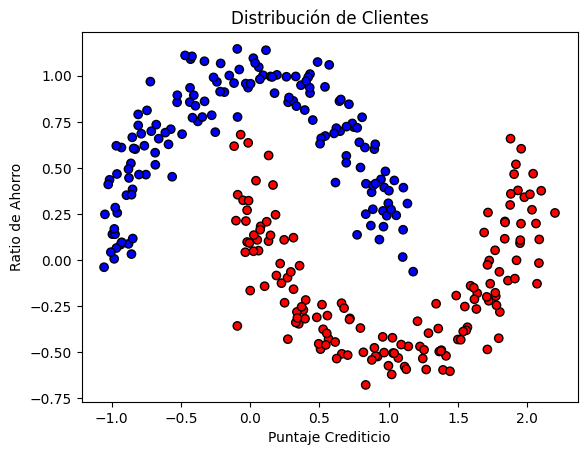

In [13]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_blobs

# Generamos datos: 300 clientes con 2 características
X, y = make_moons(n_samples=300, noise=0.1)
# Visualización inicial
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')
plt.xlabel("Puntaje Crediticio")
plt.ylabel("Ratio de Ahorro")
plt.title("Distribución de Clientes")
plt.show()